<a href="https://colab.research.google.com/github/saurabh-glitch-bit/AmulKool/blob/main/Copy_of_Untitled2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("solar_data_clean_1sec.csv")

print("Dataset shape:", df.shape)

display(df.head())


Dataset shape: (417, 6)


,Timestamp,Left LDR,Right LDR,Servo Angle,Difference,Status
0,2026-10-03 11:53:12,59,106,90,-47,NO_LIGHT
1,2026-10-03 11:53:13,58,105,90,-47,NO_LIGHT
2,2026-10-03 11:53:15,58,104,90,-46,NO_LIGHT
3,2026-10-03 11:53:16,52,96,90,-44,NO_LIGHT
4,2026-10-03 11:53:17,48,92,90,-44,NO_LIGHT


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("solar_data_clean_1sec.csv")

print("Dataset shape:", df.shape)

display(df.head(10))

Dataset shape: (417, 6)


,Timestamp,Left LDR,Right LDR,Servo Angle,Difference,Status
0,2026-10-03 11:53:12,59,106,90,-47,NO_LIGHT
1,2026-10-03 11:53:13,58,105,90,-47,NO_LIGHT
2,2026-10-03 11:53:15,58,104,90,-46,NO_LIGHT
3,2026-10-03 11:53:16,52,96,90,-44,NO_LIGHT
4,2026-10-03 11:53:17,48,92,90,-44,NO_LIGHT
5,2026-10-03 11:53:18,55,98,90,-43,NO_LIGHT
6,2026-10-03 11:53:19,59,104,90,-45,NO_LIGHT
7,2026-10-03 11:53:20,59,105,90,-46,NO_LIGHT
8,2026-10-03 11:53:21,61,108,90,-47,NO_LIGHT
9,2026-10-03 11:53:22,61,107,90,-46,NO_LIGHT


In [ ]:
print(df["Status"].value_counts())

Status
TRACKING    293
NO_LIGHT    124
Name: count, dtype: int64


In [ ]:
tracking_df = df[
    df["Status"].astype(str).str.upper() == "TRACKING"
].copy()

print("Tracking observations:", len(tracking_df))

display(tracking_df.head(10))

Tracking observations: 293


,Timestamp,Left LDR,Right LDR,Servo Angle,Difference,Status
13,2026-10-03 11:53:26,260,355,86,-95,TRACKING
14,2026-10-03 11:53:27,311,382,83,-71,TRACKING
15,2026-10-03 11:53:28,305,376,81,-71,TRACKING
16,2026-10-03 11:53:29,319,389,77,-70,TRACKING
17,2026-10-03 11:53:30,341,404,73,-63,TRACKING
18,2026-10-03 11:53:31,352,410,69,-58,TRACKING
19,2026-10-03 11:53:32,368,413,66,-45,TRACKING
20,2026-10-03 11:53:33,377,410,64,-33,TRACKING
21,2026-10-03 11:53:34,385,400,64,-15,TRACKING
22,2026-10-03 11:53:35,383,371,64,12,TRACKING


In [ ]:
X = tracking_df[
    ["Left LDR", "Right LDR", "Difference"]
]

y = tracking_df["Servo Angle"]

print("Input features (X):")
display(X.head())

print("Target (y):")
display(y.head())

Input features (X):


,Left LDR,Right LDR,Difference
13,260,355,-95
14,311,382,-71
15,305,376,-71
16,319,389,-70
17,341,404,-63


Target (y):


,Servo Angle
13,86
14,83
15,81
16,77
17,73


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 234
Testing samples: 59


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("✅ Linear Regression model trained successfully!")

✅ Linear Regression model trained successfully!


In [ ]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual Angle": y_test.values,
    "Predicted Angle": y_pred
})

display(results.head(15))

,Actual Angle,Predicted Angle
0,65,91.136792
1,90,79.844449
2,94,92.000180
3,83,89.944938
4,103,90.731630
5,120,91.021398
6,87,87.458614
7,120,90.476841
8,64,88.764064
9,69,97.025893


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R²  :", round(r2, 3))

MAE : 16.535
RMSE: 18.783
R²  : 0.227


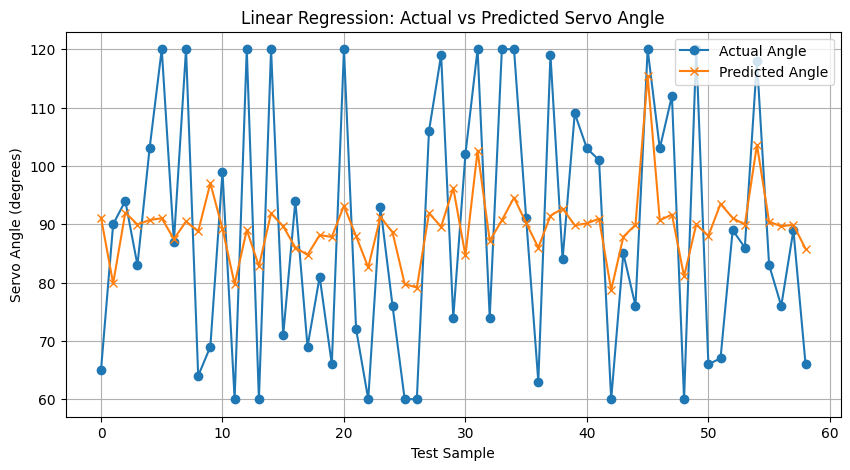

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    y_test.values,
    label="Actual Angle",
    marker="o"
)

plt.plot(
    y_pred,
    label="Predicted Angle",
    marker="x"
)

plt.xlabel("Test Sample")
plt.ylabel("Servo Angle (degrees)")
plt.title("Linear Regression: Actual vs Predicted Servo Angle")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=10
)

rf_model.fit(X_train, y_train)

print("✅ Random Forest model trained successfully!")

✅ Random Forest model trained successfully!


In [ ]:
rf_pred = rf_model.predict(X_test)

rf_results = pd.DataFrame({
    "Actual Angle": y_test.values,
    "RF Predicted Angle": rf_pred
})

display(rf_results.head(15))

,Actual Angle,RF Predicted Angle
0,65,67.064402
1,90,78.721641
2,94,86.338373
3,83,87.457722
4,103,96.549682
5,120,95.980577
6,87,76.044243
7,120,117.714325
8,64,87.065952
9,69,87.480406


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("---------------------")
print("MAE :", round(rf_mae, 3))
print("RMSE:", round(rf_rmse, 3))
print("R²  :", round(rf_r2, 3))

Random Forest Results
---------------------
MAE : 10.586
RMSE: 14.11
R²  : 0.564


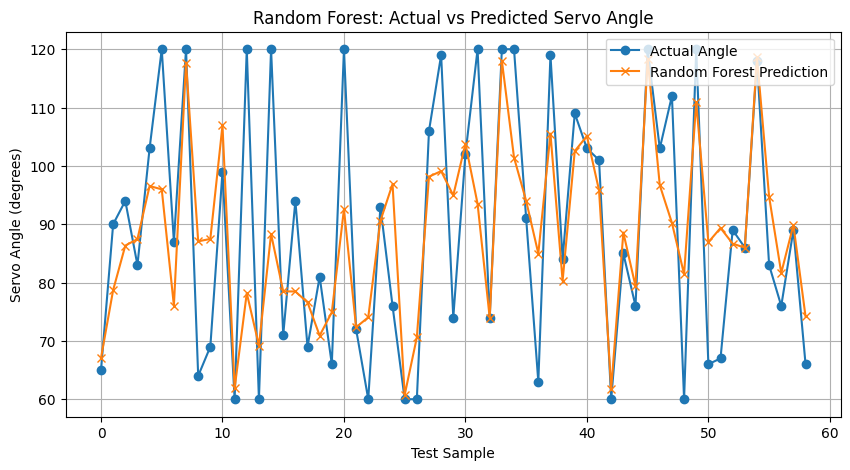

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    y_test.values,
    label="Actual Angle",
    marker="o"
)

plt.plot(
    rf_pred,
    label="Random Forest Prediction",
    marker="x"
)

plt.xlabel("Test Sample")
plt.ylabel("Servo Angle (degrees)")
plt.title("Random Forest: Actual vs Predicted Servo Angle")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

display(importance)

,Feature,Importance
0,Left LDR,0.364908
1,Right LDR,0.319707
2,Difference,0.315386


In [ ]:
ml_df = tracking_df.copy()

ml_df["Average_Light"] = (
    ml_df["Left LDR"] + ml_df["Right LDR"]
) / 2

ml_df["Absolute_Difference"] = (
    ml_df["Left LDR"] - ml_df["Right LDR"]
).abs()

ml_df["Previous_Angle"] = (
    ml_df["Servo Angle"].shift(1)
)

# Remove the first row because it has no previous angle
ml_df = ml_df.dropna().copy()

print("New ML dataset:", ml_df.shape)

display(
    ml_df[
        [
            "Left LDR",
            "Right LDR",
            "Difference",
            "Average_Light",
            "Absolute_Difference",
            "Previous_Angle",
            "Servo Angle"
        ]
    ].head(10)
)

New ML dataset: (292, 9)


,Left LDR,Right LDR,Difference,Average_Light,Absolute_Difference,Previous_Angle,Servo Angle
14,311,382,-71,346.5,71,86.0,83
15,305,376,-71,340.5,71,83.0,81
16,319,389,-70,354.0,70,81.0,77
17,341,404,-63,372.5,63,77.0,73
18,352,410,-58,381.0,58,73.0,69
19,368,413,-45,390.5,45,69.0,66
20,377,410,-33,393.5,33,66.0,64
21,385,400,-15,392.5,15,64.0,64
22,383,371,12,377.0,12,64.0,64
23,374,350,24,362.0,24,64.0,64


In [ ]:
# Features we will give to the ML model
features = [
    "Left LDR",
    "Right LDR",
    "Difference",
    "Average_Light",
    "Absolute_Difference",
    "Previous_Angle"
]

X_improved = ml_df[features]
y_improved = ml_df["Servo Angle"]

# 80% training, 20% testing — keep the original time order
split_index = int(len(ml_df) * 0.80)

X_train_improved = X_improved.iloc[:split_index]
X_test_improved = X_improved.iloc[split_index:]

y_train_improved = y_improved.iloc[:split_index]
y_test_improved = y_improved.iloc[split_index:]

print("Training samples:", len(X_train_improved))
print("Testing samples:", len(X_test_improved))

Training samples: 233
Testing samples: 59


In [ ]:
from sklearn.ensemble import RandomForestRegressor

improved_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=2,
    random_state=42
)

improved_rf.fit(
    X_train_improved,
    y_train_improved
)

print("✅ Improved Random Forest trained successfully!")

✅ Improved Random Forest trained successfully!


In [ ]:
improved_pred = improved_rf.predict(X_test_improved)

print("Predictions generated:", len(improved_pred))

display(pd.DataFrame({
    "Actual Angle": y_test_improved.values,
    "Predicted Angle": improved_pred
}).head(15))

Predictions generated: 59


,Actual Angle,Predicted Angle
0,77,79.027349
1,77,77.785159
2,76,74.740583
3,73,72.883087
4,72,70.732274
5,72,69.972512
6,70,69.972512
7,69,68.760317
8,68,70.513989
9,66,65.393373


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

improved_mae = mean_absolute_error(
    y_test_improved,
    improved_pred
)

improved_rmse = np.sqrt(
    mean_squared_error(
        y_test_improved,
        improved_pred
    )
)

improved_r2 = r2_score(
    y_test_improved,
    improved_pred
)

print("Improved Random Forest Results")
print("------------------------------")
print("MAE :", round(improved_mae, 3))
print("RMSE:", round(improved_rmse, 3))
print("R²  :", round(improved_r2, 3))

Improved Random Forest Results
------------------------------
MAE : 1.545
RMSE: 1.702
R²  : 0.982


In [ ]:
importance_improved = pd.DataFrame({
    "Feature": X_train_improved.columns,
    "Importance": improved_rf.feature_importances_
})

importance_improved = importance_improved.sort_values(
    "Importance",
    ascending=False
)

display(importance_improved)

,Feature,Importance
5,Previous_Angle,0.981740
2,Difference,0.012348
3,Average_Light,0.001830
1,Right LDR,0.001765
0,Left LDR,0.001316
4,Absolute_Difference,0.001001


In [ ]:
# Light-based ML model — WITHOUT Previous_Angle

light_features = [
    "Left LDR",
    "Right LDR",
    "Difference",
    "Average_Light",
    "Absolute_Difference"
]

X_light = ml_df[light_features]
y_light = ml_df["Servo Angle"]

# Chronological 80/20 split
split_index = int(len(ml_df) * 0.80)

X_light_train = X_light.iloc[:split_index]
X_light_test = X_light.iloc[split_index:]

y_light_train = y_light.iloc[:split_index]
y_light_test = y_light.iloc[split_index:]

print("Training samples:", len(X_light_train))
print("Testing samples:", len(X_light_test))

Training samples: 233
Testing samples: 59


In [ ]:
from sklearn.ensemble import RandomForestRegressor

light_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=2,
    random_state=42
)

light_rf.fit(
    X_light_train,
    y_light_train
)

print("✅ Light-only Random Forest trained successfully!")

✅ Light-only Random Forest trained successfully!


In [ ]:
light_pred = light_rf.predict(X_light_test)

light_results = pd.DataFrame({
    "Actual Angle": y_light_test.values,
    "Predicted Angle": light_pred
})

display(light_results.head(15))

,Actual Angle,Predicted Angle
0,77,90.096508
1,77,95.129817
2,76,97.224716
3,73,108.912646
4,72,92.538338
5,72,88.307818
6,70,84.828886
7,69,84.571394
8,68,88.072672
9,66,83.096331


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

light_mae = mean_absolute_error(
    y_light_test,
    light_pred
)

light_rmse = np.sqrt(
    mean_squared_error(
        y_light_test,
        light_pred
    )
)

light_r2 = r2_score(
    y_light_test,
    light_pred
)

print("Light-only Random Forest Results")
print("--------------------------------")
print("MAE :", round(light_mae, 3))
print("RMSE:", round(light_rmse, 3))
print("R²  :", round(light_r2, 3))

Light-only Random Forest Results
--------------------------------
MAE : 23.438
RMSE: 26.716
R²  : -3.481


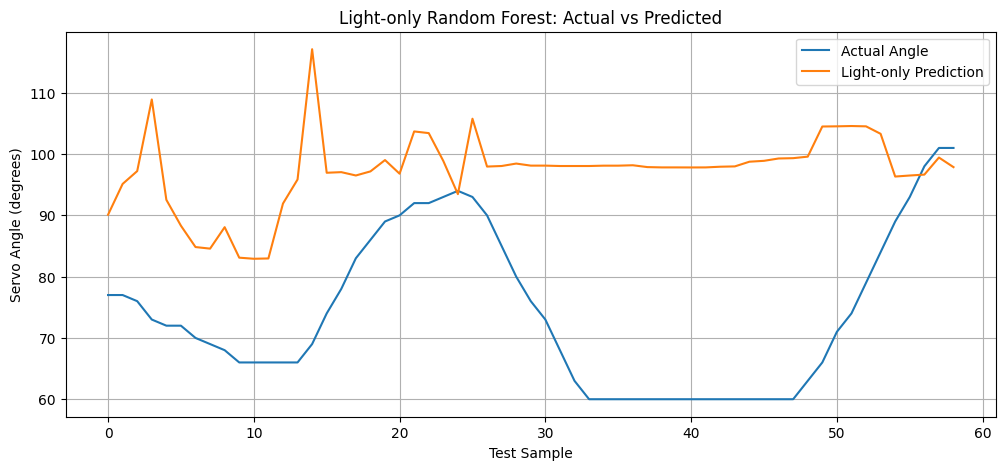

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_light_test.values,
    label="Actual Angle"
)

plt.plot(
    light_pred,
    label="Light-only Prediction"
)

plt.xlabel("Test Sample")
plt.ylabel("Servo Angle (degrees)")
plt.title("Light-only Random Forest: Actual vs Predicted")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Create movement target from consecutive servo angles

movement_df = ml_df.copy()

movement_df["Movement"] = (
    movement_df["Servo Angle"].diff()
)

# Remove the first row because it has no previous angle
movement_df = movement_df.dropna(
    subset=["Movement"]
).copy()

print("Movement dataset:", movement_df.shape)

display(
    movement_df[
        [
            "Left LDR",
            "Right LDR",
            "Difference",
            "Servo Angle",
            "Movement"
        ]
    ].head(20)
)

Movement dataset: (291, 10)


,Left LDR,Right LDR,Difference,Servo Angle,Movement
15,305,376,-71,81,-2.0
16,319,389,-70,77,-4.0
17,341,404,-63,73,-4.0
18,352,410,-58,69,-4.0
19,368,413,-45,66,-3.0
20,377,410,-33,64,-2.0
21,385,400,-15,64,0.0
22,383,371,12,64,0.0
23,374,350,24,64,0.0
24,377,334,43,69,5.0


In [ ]:
# Features for ML movement prediction

movement_features = [
    "Left LDR",
    "Right LDR",
    "Difference",
    "Average_Light",
    "Absolute_Difference",
    "Servo Angle"
]

X_movement = movement_df[movement_features]
y_movement = movement_df["Movement"]

# Chronological 80/20 split
split_index = int(len(movement_df) * 0.80)

X_movement_train = X_movement.iloc[:split_index]
X_movement_test = X_movement.iloc[split_index:]

y_movement_train = y_movement.iloc[:split_index]
y_movement_test = y_movement.iloc[split_index:]

print("Training samples:", len(X_movement_train))
print("Testing samples:", len(X_movement_test))

Training samples: 232
Testing samples: 59


In [ ]:
from sklearn.ensemble import RandomForestRegressor

movement_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
    random_state=42
)

movement_rf.fit(
    X_movement_train,
    y_movement_train
)

print("✅ Movement prediction model trained successfully!")

✅ Movement prediction model trained successfully!


In [ ]:
movement_pred = movement_rf.predict(
    X_movement_test
)

movement_results = pd.DataFrame({
    "Actual Movement": y_movement_test.values,
    "Predicted Movement": movement_pred
})

display(
    movement_results.head(20)
)

,Actual Movement,Predicted Movement
0,-2.0,-0.598995
1,0.0,-0.084026
2,-1.0,-3.535896
3,-3.0,-2.170820
4,-1.0,-2.175071
5,0.0,-1.830225
6,-2.0,-1.840114
7,-1.0,-1.369511
8,-1.0,-1.624040
9,-2.0,-2.213897


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

movement_mae = mean_absolute_error(
    y_movement_test,
    movement_pred
)

movement_rmse = np.sqrt(
    mean_squared_error(
        y_movement_test,
        movement_pred
    )
)

movement_r2 = r2_score(
    y_movement_test,
    movement_pred
)

print("Movement Prediction Random Forest")
print("---------------------------------")
print("MAE :", round(movement_mae, 3))
print("RMSE:", round(movement_rmse, 3))
print("R²  :", round(movement_r2, 3))

Movement Prediction Random Forest
---------------------------------
MAE : 3.647
RMSE: 4.661
R²  : -1.928


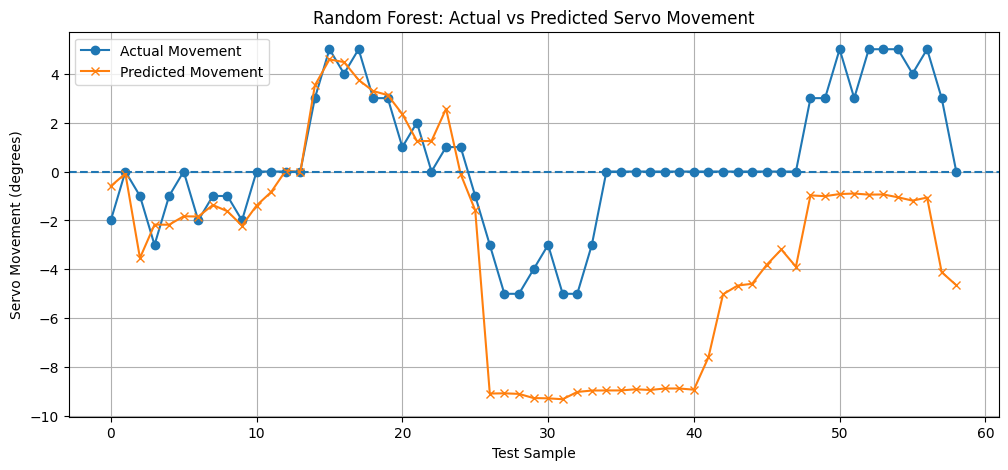

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    y_movement_test.values,
    marker="o",
    label="Actual Movement"
)

plt.plot(
    movement_pred,
    marker="x",
    label="Predicted Movement"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Test Sample")
plt.ylabel("Servo Movement (degrees)")
plt.title("Random Forest: Actual vs Predicted Servo Movement")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

movement_mae = mean_absolute_error(
    y_movement_test,
    movement_pred
)

movement_rmse = np.sqrt(
    mean_squared_error(
        y_movement_test,
        movement_pred
    )
)

movement_r2 = r2_score(
    y_movement_test,
    movement_pred
)

print("Movement Prediction Random Forest")
print("---------------------------------")
print("MAE :", round(movement_mae, 3))
print("RMSE:", round(movement_rmse, 3))
print("R²  :", round(movement_r2, 3))

Movement Prediction Random Forest
---------------------------------
MAE : 3.647
RMSE: 4.661
R²  : -1.928


In [ ]:
movement_importance = pd.DataFrame({
    "Feature": X_movement_train.columns,
    "Importance": movement_rf.feature_importances_
})

movement_importance = movement_importance.sort_values(
    "Importance",
    ascending=False
)

display(movement_importance)

,Feature,Importance
2,Difference,0.583046
5,Servo Angle,0.129921
3,Average_Light,0.129430
4,Absolute_Difference,0.089687
0,Left LDR,0.039834
1,Right LDR,0.028082


In [ ]:
print("Movement Prediction Random Forest")
print("---------------------------------")
print("MAE :", round(movement_mae, 3))
print("RMSE:", round(movement_rmse, 3))
print("R²  :", round(movement_r2, 3))

Movement Prediction Random Forest
---------------------------------
MAE : 3.647
RMSE: 4.661
R²  : -1.928


In [ ]:
import numpy as np
import pandas as pd

# Features used by the LSTM
lstm_features = [
    "Left LDR",
    "Right LDR",
    "Difference",
    "Average_Light",
    "Absolute_Difference",
    "Servo Angle"
]

# Use movement_df that we already created
lstm_data = movement_df[lstm_features + ["Movement"]].copy()

print("LSTM dataset:", lstm_data.shape)
display(lstm_data.head())

LSTM dataset: (291, 7)


,Left LDR,Right LDR,Difference,Average_Light,Absolute_Difference,Servo Angle,Movement
15,305,376,-71,340.5,71,81,-2.0
16,319,389,-70,354.0,70,77,-4.0
17,341,404,-63,372.5,63,73,-4.0
18,352,410,-58,381.0,58,69,-4.0
19,368,413,-45,390.5,45,66,-3.0


In [ ]:
from sklearn.preprocessing import MinMaxScaler

feature_scaler = MinMaxScaler()

X_scaled = feature_scaler.fit_transform(
    lstm_data[lstm_features]
)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (291, 6)


In [ ]:
sequence_length = 10

X_sequences = []
y_sequences = []

for i in range(sequence_length, len(lstm_data)):

    X_sequences.append(
        X_scaled[i-sequence_length:i]
    )

    y_sequences.append(
        lstm_data["Movement"].iloc[i]
    )

X_sequences = np.array(X_sequences)
y_sequences = np.array(y_sequences)

print("X shape:", X_sequences.shape)
print("y shape:", y_sequences.shape)

X shape: (281, 10, 6)
y shape: (281,)


In [ ]:
split_index = int(len(X_sequences) * 0.80)

X_lstm_train = X_sequences[:split_index]
X_lstm_test = X_sequences[split_index:]

y_lstm_train = y_sequences[:split_index]
y_lstm_test = y_sequences[split_index:]

print("LSTM training samples:", len(X_lstm_train))
print("LSTM testing samples:", len(X_lstm_test))

LSTM training samples: 224
LSTM testing samples: 57


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

lstm_model = Sequential([

    LSTM(
        64,
        input_shape=(
            X_lstm_train.shape[1],
            X_lstm_train.shape[2]
        )
    ),

    Dropout(0.2),

    Dense(32, activation="relu"),

    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

lstm_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,289 (79.25 KB)

 Trainable params: 20,289 (79.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = lstm_model.fit(
    X_lstm_train,
    y_lstm_train,

    epochs=100,
    batch_size=16,

    validation_data=(
        X_lstm_test,
        y_lstm_test
    ),

    shuffle=False,

    verbose=1
)

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 9.4133 - mae: 1.8549 - val_loss: 7.5672 - val_mae: 2.0099
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.2674 - mae: 1.7972 - val_loss: 7.4936 - val_mae: 2.0013
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.0907 - mae: 1.7842 - val_loss: 7.3576 - val_mae: 1.9986
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 8.8706 - mae: 1.7951 - val_loss: 7.1458 - val_mae: 2.0198
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 8.4985 - mae: 1.7902 - val_loss: 6.7033 - val_mae: 1.9944
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.2870 - mae: 1.8227 - val_loss: 6.4609 - val_mae: 2.0131
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 8.0223 - mae: 1.8367 - val_loss: 6.1141 - val_mae: 1.9895
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 7.9907 - mae: 1.8333 - val_loss: 6.1409 - val_mae: 2.0158
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - lo

In [ ]:
lstm_pred = lstm_model.predict(
    X_lstm_test
).flatten()

print("Predictions generated:", len(lstm_pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 334ms/step
Predictions generated: 57


In [ ]:
lstm_results = pd.DataFrame({
    "Actual Movement": y_lstm_test,
    "Predicted Movement": lstm_pred
})

display(
    lstm_results.head(20)
)

,Actual Movement,Predicted Movement
0,-1.0,0.229561
1,-3.0,0.721730
2,-1.0,0.606731
3,0.0,0.457257
4,-2.0,0.355237
5,-1.0,0.249256
6,-1.0,0.170708
7,-2.0,0.158707
8,0.0,0.137133
9,0.0,0.185329


In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

lstm_mae = mean_absolute_error(
    y_lstm_test,
    lstm_pred
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        y_lstm_test,
        lstm_pred
    )
)

lstm_r2 = r2_score(
    y_lstm_test,
    lstm_pred
)

print("LSTM Movement Prediction")
print("------------------------")
print("MAE :", round(lstm_mae, 3))
print("RMSE:", round(lstm_rmse, 3))
print("R²  :", round(lstm_r2, 3))

LSTM Movement Prediction
------------------------
MAE : 2.18
RMSE: 2.869
R²  : -0.087


In [ ]:
# Create target for NEXT servo angle

angle_data = movement_df.copy()

angle_data["Next_Angle"] = angle_data["Servo Angle"].shift(-1)

# Remove last row because it has no next angle
angle_data = angle_data.dropna(
    subset=["Next_Angle"]
).copy()

print("Angle prediction dataset:", angle_data.shape)

display(
    angle_data[
        [
            "Left LDR",
            "Right LDR",
            "Difference",
            "Servo Angle",
            "Next_Angle"
        ]
    ].head(15)
)

Angle prediction dataset: (290, 11)


,Left LDR,Right LDR,Difference,Servo Angle,Next_Angle
15,305,376,-71,81,77.0
16,319,389,-70,77,73.0
17,341,404,-63,73,69.0
18,352,410,-58,69,66.0
19,368,413,-45,66,64.0
20,377,410,-33,64,64.0
21,385,400,-15,64,64.0
22,383,371,12,64,64.0
23,374,350,24,64,69.0
24,377,334,43,69,72.0


In [ ]:
angle_features = [
    "Left LDR",
    "Right LDR",
    "Difference",
    "Average_Light",
    "Absolute_Difference",
    "Servo Angle"
]

X_angle = angle_data[angle_features]
y_angle = angle_data["Next_Angle"]

print("Features:", X_angle.shape)
print("Target:", y_angle.shape)

Features: (290, 6)
Target: (290,)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

angle_scaler = MinMaxScaler()

X_angle_scaled = angle_scaler.fit_transform(
    X_angle
)

print("Scaled feature shape:", X_angle_scaled.shape)

Scaled feature shape: (290, 6)


In [ ]:
sequence_length = 10

X_angle_sequences = []
y_angle_sequences = []

for i in range(sequence_length, len(angle_data)):

    X_angle_sequences.append(
        X_angle_scaled[i-sequence_length:i]
    )

    y_angle_sequences.append(
        y_angle.iloc[i]
    )

X_angle_sequences = np.array(X_angle_sequences)
y_angle_sequences = np.array(y_angle_sequences)

print("X shape:", X_angle_sequences.shape)
print("y shape:", y_angle_sequences.shape)

X shape: (280, 10, 6)
y shape: (280,)


In [ ]:
split_index = int(len(X_angle_sequences) * 0.80)

X_angle_train = X_angle_sequences[:split_index]
X_angle_test = X_angle_sequences[split_index:]

y_angle_train = y_angle_sequences[:split_index]
y_angle_test = y_angle_sequences[split_index:]

print("Training samples:", len(X_angle_train))
print("Testing samples:", len(X_angle_test))

Training samples: 224
Testing samples: 56


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

angle_lstm = Sequential([

    LSTM(
        64,
        input_shape=(
            X_angle_train.shape[1],
            X_angle_train.shape[2]
        )
    ),

    Dropout(0.2),

    Dense(
        32,
        activation="relu"
    ),

    Dense(1)
])

angle_lstm.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

angle_lstm.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,289 (79.25 KB)

 Trainable params: 20,289 (79.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
angle_history = angle_lstm.fit(
    X_angle_train,
    y_angle_train,

    epochs=100,
    batch_size=16,

    validation_data=(
        X_angle_test,
        y_angle_test
    ),

    shuffle=False,

    verbose=1
)

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 9398.8096 - mae: 95.2092 - val_loss: 5492.8789 - val_mae: 72.9988
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 8899.4473 - mae: 92.4954 - val_loss: 4894.2612 - val_mae: 68.7965
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7886.9180 - mae: 86.7822 - val_loss: 3933.2441 - val_mae: 61.3796
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6645.1323 - mae: 79.3175 - val_loss: 3013.7500 - val_mae: 53.3576
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5441.2227 - mae: 71.3136 - val_loss: 2212.3318 - val_mae: 45.2259
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4288.1650 - mae: 62.5695 - val_loss: 1483.4377 - val_mae: 36.2825
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3188.6233 - mae: 53.1735 - val_loss: 888.8774 - val_mae: 26.8670
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2378.8127 - mae: 44.8374 - val_loss: 476.3100 - val_mae: 17

In [ ]:
angle_pred = angle_lstm.predict(
    X_angle_test
).flatten()

print("Predictions generated:", len(angle_pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 348ms/step
Predictions generated: 56


In [ ]:
angle_results = pd.DataFrame({
    "Actual Angle": y_angle_test,
    "Predicted Angle": angle_pred
})

display(angle_results.head(20))

,Actual Angle,Predicted Angle
0,73.0,80.312454
1,72.0,81.050568
2,72.0,79.878433
3,70.0,78.461090
4,69.0,77.108917
5,68.0,75.752769
6,66.0,74.495216
7,66.0,73.434120
8,66.0,72.359848
9,66.0,71.443481


In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

lstm_angle_mae = mean_absolute_error(
    y_angle_test,
    angle_pred
)

lstm_angle_rmse = np.sqrt(
    mean_squared_error(
        y_angle_test,
        angle_pred
    )
)

lstm_angle_r2 = r2_score(
    y_angle_test,
    angle_pred
)

print("LSTM Servo Angle Prediction")
print("---------------------------")
print("MAE :", round(lstm_angle_mae, 3))
print("RMSE:", round(lstm_angle_rmse, 3))
print("R²  :", round(lstm_angle_r2, 3))

LSTM Servo Angle Prediction
---------------------------
MAE : 19.266
RMSE: 23.797
R²  : -2.382


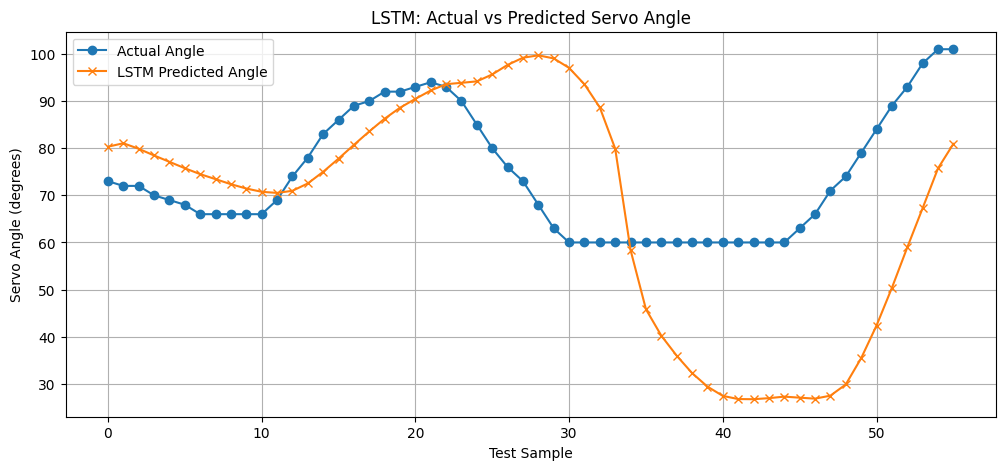

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    y_angle_test,
    marker="o",
    label="Actual Angle"
)

plt.plot(
    angle_pred,
    marker="x",
    label="LSTM Predicted Angle"
)

plt.xlabel("Test Sample")
plt.ylabel("Servo Angle (degrees)")
plt.title("LSTM: Actual vs Predicted Servo Angle")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

lstm_angle_mae = mean_absolute_error(
    y_angle_test,
    angle_pred
)

lstm_angle_rmse = np.sqrt(
    mean_squared_error(
        y_angle_test,
        angle_pred
    )
)

lstm_angle_r2 = r2_score(
    y_angle_test,
    angle_pred
)

print("LSTM Servo Angle Prediction")
print("---------------------------")
print("MAE :", round(lstm_angle_mae, 3))
print("RMSE:", round(lstm_angle_rmse, 3))
print("R²  :", round(lstm_angle_r2, 3))

LSTM Servo Angle Prediction
---------------------------
MAE : 19.266
RMSE: 23.797
R²  : -2.382


In [ ]:
print("Columns in ML dataset:")
print(ml_df.columns.tolist())

print("\nDataset shape:")
print(ml_df.shape)

display(ml_df.head())

Columns in ML dataset:
['Timestamp', 'Left LDR', 'Right LDR', 'Servo Angle', 'Difference', 'Status', 'Average_Light', 'Absolute_Difference', 'Previous_Angle']

Dataset shape:
(292, 9)


,Timestamp,Left LDR,Right LDR,Servo Angle,Difference,Status,Average_Light,Absolute_Difference,Previous_Angle
14,2026-10-03 11:53:27,311,382,83,-71,TRACKING,346.5,71,86.0
15,2026-10-03 11:53:28,305,376,81,-71,TRACKING,340.5,71,83.0
16,2026-10-03 11:53:29,319,389,77,-70,TRACKING,354.0,70,81.0
17,2026-10-03 11:53:30,341,404,73,-63,TRACKING,372.5,63,77.0
18,2026-10-03 11:53:31,352,410,69,-58,TRACKING,381.0,58,73.0


In [ ]:
import numpy as np
import pandas as pd

# Make a copy of the real Arduino dataset
energy_df = ml_df.copy()

# Make sure timestamp is datetime
energy_df["Timestamp"] = pd.to_datetime(
    energy_df["Timestamp"]
)

# --------------------------------------------------
# 1. Estimate normalized light intensity
# --------------------------------------------------

light_min = energy_df["Average_Light"].min()
light_max = energy_df["Average_Light"].max()

energy_df["Light_Normalized"] = (
    (energy_df["Average_Light"] - light_min) /
    (light_max - light_min)
)

# --------------------------------------------------
# 2. Estimate tracking efficiency
# --------------------------------------------------
# Smaller LDR difference = better alignment.
# This is a SIMULATION assumption, not a measured value.

max_diff = energy_df["Absolute_Difference"].max()

energy_df["Tracking_Efficiency"] = (
    1 -
    energy_df["Absolute_Difference"] /
    max_diff
).clip(0.1, 1.0)

# --------------------------------------------------
# 3. Simulated solar power
# --------------------------------------------------

MAX_POWER = 100.0   # simulated maximum power in watts

noise = np.random.normal(
    0,
    2,
    len(energy_df)
)

energy_df["Simulated_Power_W"] = (
    MAX_POWER
    * energy_df["Light_Normalized"]
    * energy_df["Tracking_Efficiency"]
    + noise
)

# Prevent negative power
energy_df["Simulated_Power_W"] = (
    energy_df["Simulated_Power_W"]
    .clip(lower=0)
)

print(
    "Energy dataset shape:",
    energy_df.shape
)

display(
    energy_df[
        [
            "Timestamp",
            "Left LDR",
            "Right LDR",
            "Difference",
            "Servo Angle",
            "Average_Light",
            "Absolute_Difference",
            "Simulated_Power_W"
        ]
    ].head(20)
)


NameError: name 'ml_df' is not defined

In [ ]:
print(df.shape)
print(df.columns.tolist())

NameError: name 'df' is not defined

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving solar_data_clean_1sec.csv to solar_data_clean_1sec.csv


In [ ]:
import pandas as pd
import io

filename = list(uploaded.keys())[0]

df = pd.read_csv(
    io.BytesIO(uploaded[filename])
)

print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

display(df.head())

Dataset shape: (417, 6)
Columns:
['Timestamp', 'Left LDR', 'Right LDR', 'Servo Angle', 'Difference', 'Status']


,Timestamp,Left LDR,Right LDR,Servo Angle,Difference,Status
0,2026-10-03 11:53:12,59,106,90,-47,NO_LIGHT
1,2026-10-03 11:53:13,58,105,90,-47,NO_LIGHT
2,2026-10-03 11:53:15,58,104,90,-46,NO_LIGHT
3,2026-10-03 11:53:16,52,96,90,-44,NO_LIGHT
4,2026-10-03 11:53:17,48,92,90,-44,NO_LIGHT


In [ ]:
# Make a copy of the uploaded data
ml_df = df.copy()

# Convert timestamp
ml_df["Timestamp"] = pd.to_datetime(
    ml_df["Timestamp"]
)

# Create derived ML features
ml_df["Average_Light"] = (
    ml_df["Left LDR"] +
    ml_df["Right LDR"]
) / 2

ml_df["Absolute_Difference"] = (
    ml_df["Difference"].abs()
)

ml_df["Previous_Angle"] = (
    ml_df["Servo Angle"].shift(1)
)

# Remove first row because it has no previous angle
ml_df = ml_df.dropna(
    subset=["Previous_Angle"]
).copy()

print("ML dataset shape:", ml_df.shape)

print("\nColumns:")
print(ml_df.columns.tolist())

display(ml_df.head())

ML dataset shape: (416, 9)

Columns:
['Timestamp', 'Left LDR', 'Right LDR', 'Servo Angle', 'Difference', 'Status', 'Average_Light', 'Absolute_Difference', 'Previous_Angle']


,Timestamp,Left LDR,Right LDR,Servo Angle,Difference,Status,Average_Light,Absolute_Difference,Previous_Angle
1,2026-10-03 11:53:13,58,105,90,-47,NO_LIGHT,81.5,47,90.0
2,2026-10-03 11:53:15,58,104,90,-46,NO_LIGHT,81.0,46,90.0
3,2026-10-03 11:53:16,52,96,90,-44,NO_LIGHT,74.0,44,90.0
4,2026-10-03 11:53:17,48,92,90,-44,NO_LIGHT,70.0,44,90.0
5,2026-10-03 11:53:18,55,98,90,-43,NO_LIGHT,76.5,43,90.0


In [ ]:
tracking_df = ml_df[
    ml_df["Status"] == "TRACKING"
].copy()

print("Tracking observations:", len(tracking_df))

display(
    tracking_df[
        [
            "Timestamp",
            "Left LDR",
            "Right LDR",
            "Difference",
            "Servo Angle",
            "Average_Light",
            "Absolute_Difference",
            "Previous_Angle"
        ]
    ].head(10)
)


Tracking observations: 293


,Timestamp,Left LDR,Right LDR,Difference,Servo Angle,Average_Light,Absolute_Difference,Previous_Angle
13,2026-10-03 11:53:26,260,355,-95,86,307.5,95,90.0
14,2026-10-03 11:53:27,311,382,-71,83,346.5,71,86.0
15,2026-10-03 11:53:28,305,376,-71,81,340.5,71,83.0
16,2026-10-03 11:53:29,319,389,-70,77,354.0,70,81.0
17,2026-10-03 11:53:30,341,404,-63,73,372.5,63,77.0
18,2026-10-03 11:53:31,352,410,-58,69,381.0,58,73.0
19,2026-10-03 11:53:32,368,413,-45,66,390.5,45,69.0
20,2026-10-03 11:53:33,377,410,-33,64,393.5,33,66.0
21,2026-10-03 11:53:34,385,400,-15,64,392.5,15,64.0
22,2026-10-03 11:53:35,383,371,12,64,377.0,12,64.0


In [ ]:
import numpy as np
import pandas as pd

# Work with the real tracking observations
energy_df = tracking_df.copy()

# Make sure data is chronological
energy_df = energy_df.sort_values(
    "Timestamp"
).reset_index(drop=True)

# -----------------------------
# 1. Normalize light intensity
# -----------------------------

light_min = energy_df["Average_Light"].min()
light_max = energy_df["Average_Light"].max()

energy_df["Light_Normalized"] = (
    (energy_df["Average_Light"] - light_min)
    / (light_max - light_min)
)

# -----------------------------
# 2. Simulated tracking efficiency
# -----------------------------

max_difference = energy_df[
    "Absolute_Difference"
].max()

energy_df["Tracking_Efficiency"] = (
    1
    - (
        energy_df["Absolute_Difference"]
        / max_difference
    )
)

# Keep efficiency within a reasonable
# simulated range
energy_df["Tracking_Efficiency"] = (
    energy_df["Tracking_Efficiency"]
    .clip(0.10, 1.0)
)

# -----------------------------
# 3. Generate simulated power
# -----------------------------

MAX_POWER = 100.0

np.random.seed(42)

noise = np.random.normal(
    loc=0,
    scale=2,
    size=len(energy_df)
)

energy_df["Simulated_Power_W"] = (
    MAX_POWER
    * energy_df["Light_Normalized"]
    * energy_df["Tracking_Efficiency"]
    + noise
)

# Power cannot be negative
energy_df["Simulated_Power_W"] = (
    energy_df["Simulated_Power_W"]
    .clip(lower=0)
)

print(
    "Energy dataset shape:",
    energy_df.shape
)

display(
    energy_df[
        [
            "Timestamp",
            "Left LDR",
            "Right LDR",
            "Difference",
            "Servo Angle",
            "Average_Light",
            "Absolute_Difference",
            "Simulated_Power_W"
        ]
    ].head(15)
)

Energy dataset shape: (293, 12)


,Timestamp,Left LDR,Right LDR,Difference,Servo Angle,Average_Light,Absolute_Difference,Simulated_Power_W
0,2026-10-03 11:53:26,260,355,-95,86,307.5,95,31.631726
1,2026-10-03 11:53:27,311,382,-71,83,346.5,71,39.725829
2,2026-10-03 11:53:28,305,376,-71,81,340.5,71,40.154810
3,2026-10-03 11:53:29,319,389,-70,77,354.0,70,44.579625
4,2026-10-03 11:53:30,341,404,-63,73,372.5,63,45.376922
5,2026-10-03 11:53:31,352,410,-58,69,381.0,58,47.604573
6,2026-10-03 11:53:32,368,413,-45,66,390.5,45,54.656039
7,2026-10-03 11:53:33,377,410,-33,64,393.5,33,55.094839
8,2026-10-03 11:53:34,385,400,-15,64,392.5,15,54.585304
9,2026-10-03 11:53:35,383,371,12,64,377.0,12,53.587743


In [ ]:
# Create next-step power target

energy_df["Next_Power_W"] = (
    energy_df["Simulated_Power_W"].shift(-1)
)

# Last row has no next observation
energy_ml = energy_df.dropna(
    subset=["Next_Power_W"]
).copy()

print(
    "Energy ML dataset:",
    energy_ml.shape
)

display(
    energy_ml[
        [
            "Timestamp",
            "Average_Light",
            "Absolute_Difference",
            "Servo Angle",
            "Simulated_Power_W",
            "Next_Power_W"
        ]
    ].head(15)
)

Energy ML dataset: (292, 13)


,Timestamp,Average_Light,Absolute_Difference,Servo Angle,Simulated_Power_W,Next_Power_W
0,2026-10-03 11:53:26,307.5,95,86,31.631726,39.725829
1,2026-10-03 11:53:27,346.5,71,83,39.725829,40.154810
2,2026-10-03 11:53:28,340.5,71,81,40.154810,44.579625
3,2026-10-03 11:53:29,354.0,70,77,44.579625,45.376922
4,2026-10-03 11:53:30,372.5,63,73,45.376922,47.604573
5,2026-10-03 11:53:31,381.0,58,69,47.604573,54.656039
6,2026-10-03 11:53:32,390.5,45,66,54.656039,55.094839
7,2026-10-03 11:53:33,393.5,33,64,55.094839,54.585304
8,2026-10-03 11:53:34,392.5,15,64,54.585304,53.587743
9,2026-10-03 11:53:35,377.0,12,64,53.587743,47.025307


In [ ]:
# 80% training, 20% testing
energy_split = int(len(X_energy) * 0.80)

X_energy_train = X_energy.iloc[:energy_split]
X_energy_test = X_energy.iloc[energy_split:]

y_energy_train = y_energy.iloc[:energy_split]
y_energy_test = y_energy.iloc[energy_split:]

print("Training samples:", len(X_energy_train))
print("Testing samples:", len(X_energy_test))

NameError: name 'X_energy' is not defined

In [ ]:
energy_features = [
    "Left LDR",
    "Right LDR",
    "Difference",
    "Average_Light",
    "Absolute_Difference",
    "Servo Angle",
    "Simulated_Power_W"
]

X_energy = energy_ml[energy_features].copy()

y_energy = energy_ml["Next_Power_W"].copy()

print("Input features:", X_energy.shape)
print("Target:", y_energy.shape)

print("\nFeatures:")
print(X_energy.columns.tolist())

Input features: (292, 7)
Target: (292,)

Features:
['Left LDR', 'Right LDR', 'Difference', 'Average_Light', 'Absolute_Difference', 'Servo Angle', 'Simulated_Power_W']


In [ ]:
energy_ml = energy_ml.rename(
    columns={
        "Simulated_Power_W": "Power_W"
    }
)

print(energy_ml.columns.tolist())

['Timestamp', 'Left LDR', 'Right LDR', 'Servo Angle', 'Difference', 'Status', 'Average_Light', 'Absolute_Difference', 'Previous_Angle', 'Light_Normalized', 'Tracking_Efficiency', 'Power_W', 'Next_Power_W']


In [ ]:
energy_features = [
    "Left LDR",
    "Right LDR",
    "Difference",
    "Average_Light",
    "Absolute_Difference",
    "Servo Angle",
    "Power_W"
]

X_energy = energy_ml[energy_features].copy()

y_energy = energy_ml["Next_Power_W"].copy()

print("Input features:", X_energy.shape)
print("Target:", y_energy.shape)

Input features: (292, 7)
Target: (292,)


In [ ]:
energy_split = int(len(X_energy) * 0.80)

X_energy_train = X_energy.iloc[:energy_split]
X_energy_test = X_energy.iloc[energy_split:]

y_energy_train = y_energy.iloc[:energy_split]
y_energy_test = y_energy.iloc[energy_split:]

print("Training samples:", len(X_energy_train))
print("Testing samples:", len(X_energy_test))

Training samples: 233
Testing samples: 59


In [ ]:
from sklearn.ensemble import RandomForestRegressor

power_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

power_rf.fit(
    X_energy_train,
    y_energy_train
)

print("Power forecasting Random Forest trained successfully!")

Power forecasting Random Forest trained successfully!


In [ ]:
power_predictions = power_rf.predict(
    X_energy_test
)

print(
    "Predictions generated:",
    len(power_predictions)
)

Predictions generated: 59


In [ ]:
power_results = pd.DataFrame({
    "Actual Next Power (W)": y_energy_test.to_numpy(),
    "Predicted Next Power (W)": power_predictions
})

display(power_results.head(20))

,Actual Next Power (W),Predicted Next Power (W)
0,65.509790,60.853173
1,64.439878,61.546537
2,59.225485,61.335643
3,64.433261,62.250899
4,61.861433,63.885827
5,64.965313,61.383142
6,61.465586,63.086005
7,62.857696,61.130550
8,64.415644,62.424625
9,63.070345,62.653300


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

power_mae = mean_absolute_error(
    y_energy_test,
    power_predictions
)

power_rmse = np.sqrt(
    mean_squared_error(
        y_energy_test,
        power_predictions
    )
)

power_r2 = r2_score(
    y_energy_test,
    power_predictions
)

print("Power Forecasting - Random Forest")
print("----------------------------------")
print("MAE :", round(power_mae, 3), "W")
print("RMSE:", round(power_rmse, 3), "W")
print("R²  :", round(power_r2, 3))

Power Forecasting - Random Forest
----------------------------------
MAE : 17.936 W
RMSE: 22.077 W
R²  : 0.529


In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X_energy_train.columns,
    "Importance": power_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
6,Power_W,0.594021
1,Right LDR,0.244979
3,Average_Light,0.043569
4,Absolute_Difference,0.040037
5,Servo Angle,0.028631
0,Left LDR,0.026667
2,Difference,0.022096


In [ ]:
# Remove current Power_W from the input features

light_features = [
    "Left LDR",
    "Right LDR",
    "Difference",
    "Average_Light",
    "Absolute_Difference",
    "Servo Angle"
]

X_light = energy_ml[light_features].copy()
y_light = energy_ml["Next_Power_W"].copy()

# Chronological 80/20 split
split = int(len(X_light) * 0.80)

X_light_train = X_light.iloc[:split]
X_light_test = X_light.iloc[split:]

y_light_train = y_light.iloc[:split]
y_light_test = y_light.iloc[split:]

print("Training samples:", len(X_light_train))
print("Testing samples:", len(X_light_test))
print("Features:", X_light.columns.tolist())

Training samples: 233
Testing samples: 59
Features: ['Left LDR', 'Right LDR', 'Difference', 'Average_Light', 'Absolute_Difference', 'Servo Angle']


In [ ]:
light_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

light_rf.fit(
    X_light_train,
    y_light_train
)

light_predictions = light_rf.predict(
    X_light_test
)

print("Light + Tracking Random Forest trained successfully!")

Light + Tracking Random Forest trained successfully!


In [ ]:
light_mae = mean_absolute_error(
    y_light_test,
    light_predictions
)

light_rmse = np.sqrt(
    mean_squared_error(
        y_light_test,
        light_predictions
    )
)

light_r2 = r2_score(
    y_light_test,
    light_predictions
)

print("Light + Tracking Power Forecasting")
print("-----------------------------------")
print("MAE :", round(light_mae, 3), "W")
print("RMSE:", round(light_rmse, 3), "W")
print("R²  :", round(light_r2, 3))

Light + Tracking Power Forecasting
-----------------------------------
MAE : 17.868 W
RMSE: 21.963 W
R²  : 0.534


In [ ]:
light_importance = pd.DataFrame({
    "Feature": X_light_train.columns,
    "Importance": light_rf.feature_importances_
})

light_importance = light_importance.sort_values(
    "Importance",
    ascending=False
)

display(light_importance)

,Feature,Importance
1,Right LDR,0.567974
3,Average_Light,0.270990
4,Absolute_Difference,0.057611
0,Left LDR,0.038183
2,Difference,0.034404
5,Servo Angle,0.030838


In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_light_test.to_numpy(),
    marker="o",
    label="Actual Next Power"
)

plt.plot(
    light_predictions,
    marker="x",
    label="Predicted Next Power"
)

plt.xlabel("Test Sample")
plt.ylabel("Power (W)")
plt.title("Actual vs Predicted Next Power")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



NameError: name 'plt' is not defined

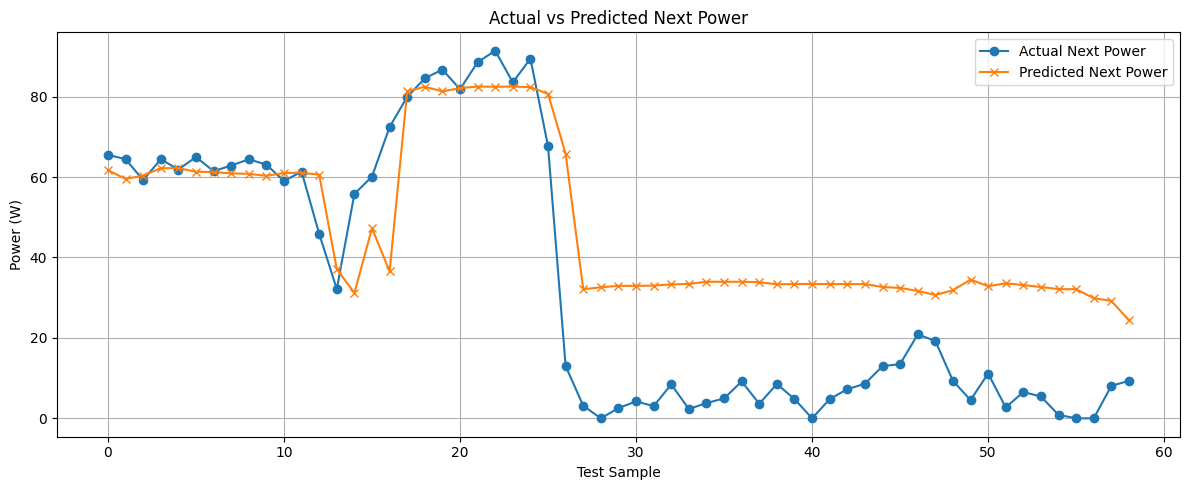

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    y_light_test.to_numpy(),
    marker="o",
    label="Actual Next Power"
)

plt.plot(
    light_predictions,
    marker="x",
    label="Predicted Next Power"
)

plt.xlabel("Test Sample")
plt.ylabel("Power (W)")
plt.title("Actual vs Predicted Next Power")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

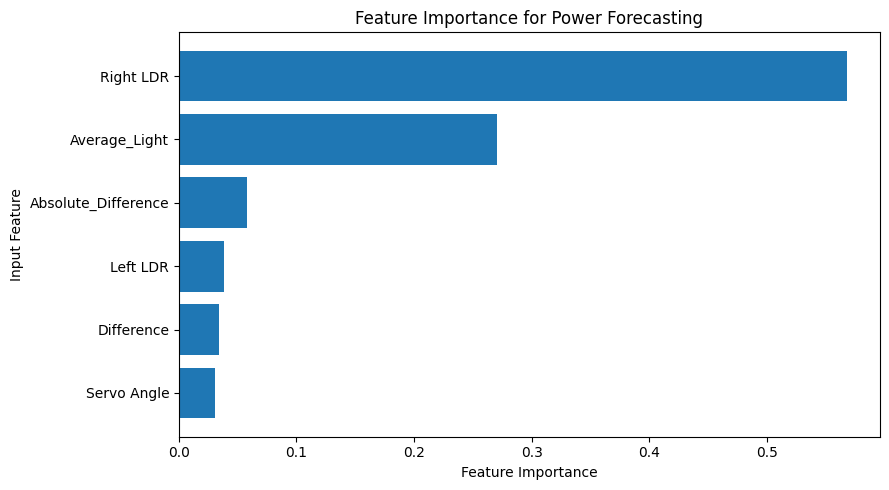

In [ ]:
plt.figure(figsize=(9, 5))

plt.barh(
    light_importance["Feature"],
    light_importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Input Feature")
plt.title("Feature Importance for Power Forecasting")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

               Feature  Importance
5          Servo Angle    0.030838
2           Difference    0.034404
0             Left LDR    0.038183
4  Absolute_Difference    0.057611
3        Average_Light    0.270990
1            Right LDR    0.567974


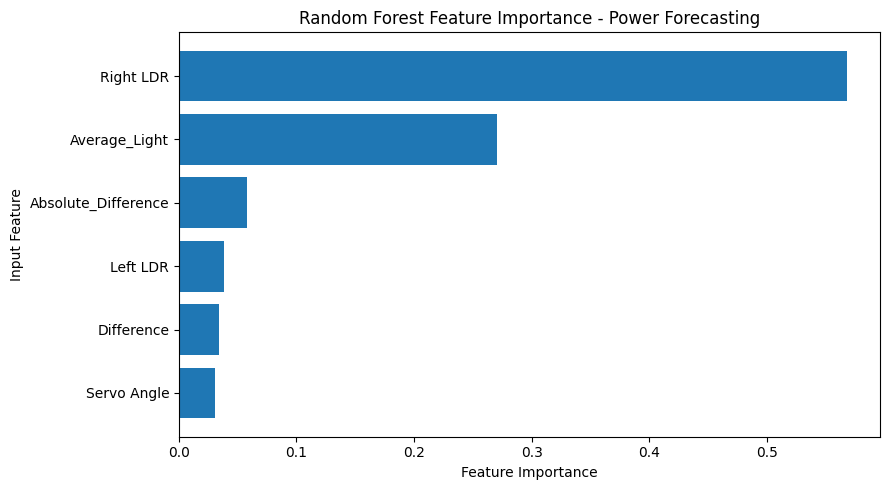

In [ ]:
# Recreate feature importance directly from the current model

light_importance_final = pd.DataFrame({
    "Feature": X_light_train.columns,
    "Importance": light_rf.feature_importances_
}).sort_values(
    "Importance",
    ascending=True
)

print(light_importance_final)

plt.figure(figsize=(9, 5))

plt.barh(
    light_importance_final["Feature"],
    light_importance_final["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Input Feature")
plt.title("Random Forest Feature Importance - Power Forecasting")

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_angle_test.to_numpy(),
    marker="o",
    label="Actual Servo Angle"
)

plt.plot(
    angle_predictions,
    marker="x",
    label="Predicted Servo Angle"
)

plt.xlabel("Test Sample")
plt.ylabel("Servo Angle (degrees)")
plt.title("Random Forest: Actual vs Predicted Servo Angle")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

NameError: name 'y_angle_test' is not defined

<Figure size 1200x500 with 0 Axes>

In [ ]:
# Create the angle prediction dataset

angle_df = ml_df.copy()

# Target = current Servo Angle
angle_features = [
    "Left LDR",
    "Right LDR",
    "Difference",
    "Average_Light",
    "Absolute_Difference",
    "Previous_Angle"
]

X_angle = angle_df[angle_features].copy()
y_angle = angle_df["Servo Angle"].copy()

print("Features:", X_angle.shape)
print("Target:", y_angle.shape)

Features: (416, 6)
Target: (416,)


In [ ]:
# Keep only observations where the tracker was actually tracking light

angle_df = ml_df[
    ml_df["Status"] == "TRACKING"
].copy()

print("Tracking observations:", len(angle_df))

Tracking observations: 293


In [ ]:
angle_df = ml_df[
    ml_df["Status"] == "TRACKING"
].copy()

print("Tracking observations:", len(angle_df))


Tracking observations: 293


In [ ]:
angle_features = [
    "Left LDR",
    "Right LDR",
    "Difference",
    "Average_Light",
    "Absolute_Difference",
    "Previous_Angle"
]

X_angle = angle_df[angle_features].copy()
y_angle = angle_df["Servo Angle"].copy()

print("Features:", X_angle.shape)
print("Target:", y_angle.shape)

Features: (293, 6)
Target: (293,)


In [ ]:
angle_data = pd.concat(
    [X_angle, y_angle.rename("Servo Angle")],
    axis=1
).dropna()

X_angle = angle_data[angle_features].copy()
y_angle = angle_data["Servo Angle"].copy()

print("Final angle dataset:", X_angle.shape)

Final angle dataset: (293, 6)


In [ ]:
angle_split = int(len(X_angle) * 0.80)

X_angle_train = X_angle.iloc[:angle_split]
X_angle_test = X_angle.iloc[angle_split:]

y_angle_train = y_angle.iloc[:angle_split]
y_angle_test = y_angle.iloc[angle_split:]

print("Training samples:", len(X_angle_train))
print("Testing samples:", len(X_angle_test))

Training samples: 234
Testing samples: 59


In [ ]:
from sklearn.ensemble import RandomForestRegressor

angle_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

angle_rf.fit(
    X_angle_train,
    y_angle_train
)

angle_predictions = angle_rf.predict(
    X_angle_test
)

print("Angle predictions generated:", len(angle_predictions))

Angle predictions generated: 59


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

angle_mae = mean_absolute_error(
    y_angle_test,
    angle_predictions
)

angle_rmse = np.sqrt(
    mean_squared_error(
        y_angle_test,
        angle_predictions
    )
)

angle_r2 = r2_score(
    y_angle_test,
    angle_predictions
)

print("Servo Angle Prediction - Random Forest")
print("---------------------------------------")
print("MAE :", round(angle_mae, 3), "degrees")
print("RMSE:", round(angle_rmse, 3), "degrees")
print("R²  :", round(angle_r2, 3))

Servo Angle Prediction - Random Forest
---------------------------------------
MAE : 1.574 degrees
RMSE: 1.751 degrees
R²  : 0.981


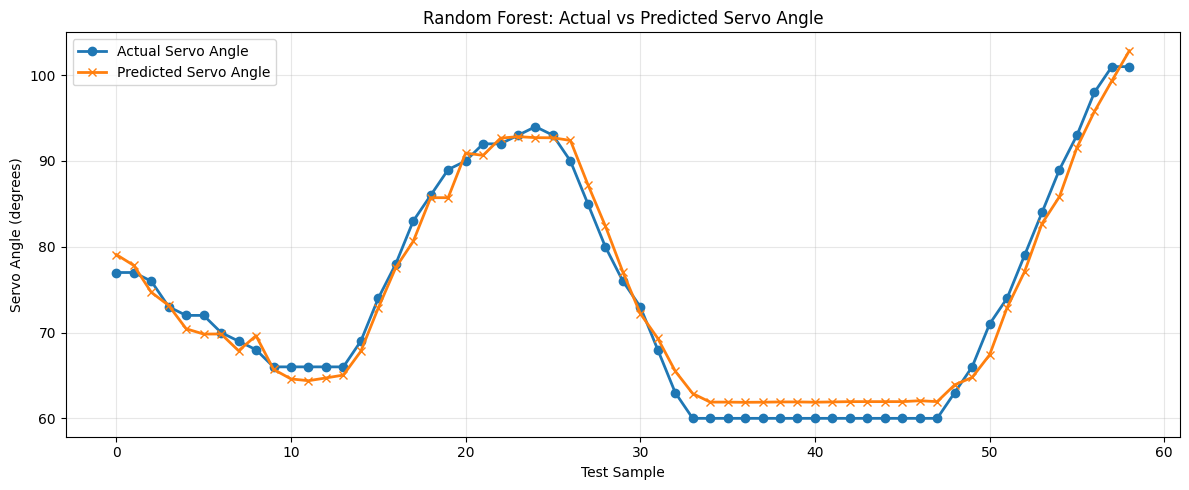

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    y_angle_test.to_numpy(),
    marker="o",
    linewidth=2,
    label="Actual Servo Angle"
)

plt.plot(
    angle_predictions,
    marker="x",
    linewidth=2,
    label="Predicted Servo Angle"
)

plt.xlabel("Test Sample")
plt.ylabel("Servo Angle (degrees)")
plt.title(
    "Random Forest: Actual vs Predicted Servo Angle"
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

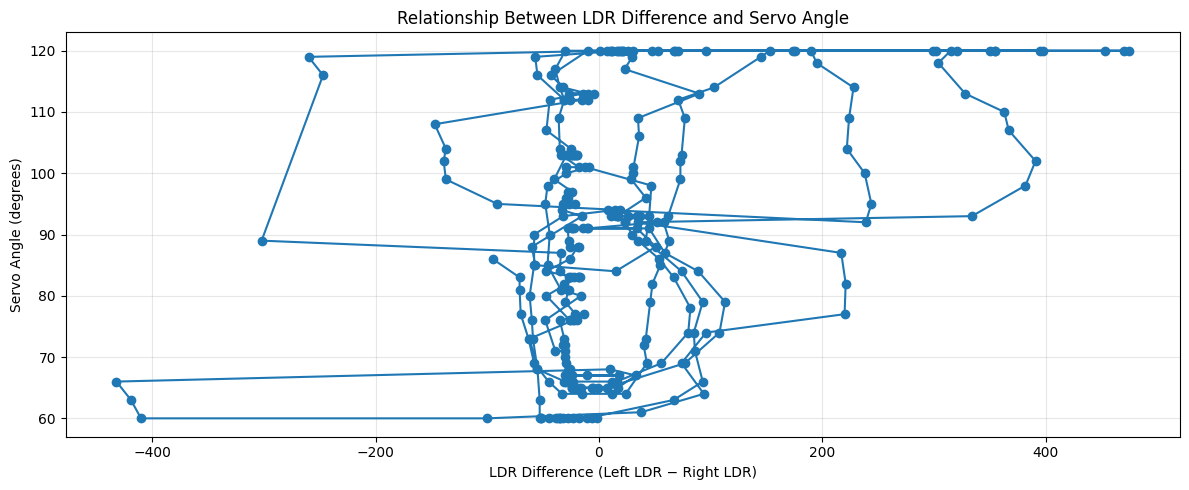

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    angle_df["Difference"].to_numpy(),
    angle_df["Servo Angle"].to_numpy(),
    marker="o",
    linestyle="-"
)

plt.xlabel("LDR Difference (Left LDR − Right LDR)")
plt.ylabel("Servo Angle (degrees)")
plt.title("Relationship Between LDR Difference and Servo Angle")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

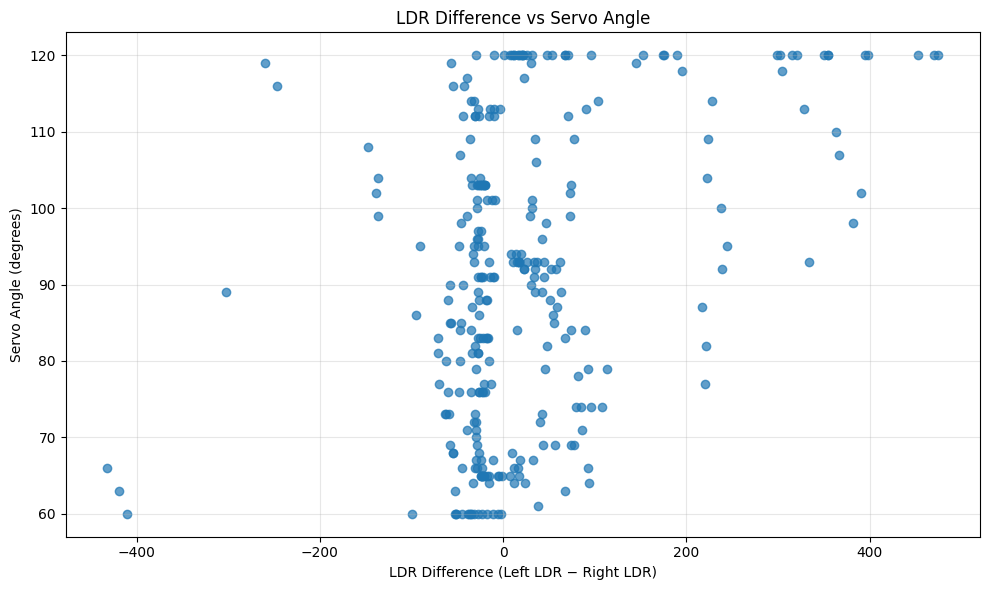

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    angle_df["Difference"],
    angle_df["Servo Angle"],
    alpha=0.7
)

plt.xlabel("LDR Difference (Left LDR − Right LDR)")
plt.ylabel("Servo Angle (degrees)")
plt.title("LDR Difference vs Servo Angle")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

               Feature  Importance
4  Absolute_Difference    0.001204
0             Left LDR    0.001326
3        Average_Light    0.001653
1            Right LDR    0.002073
2           Difference    0.009295
5       Previous_Angle    0.984449


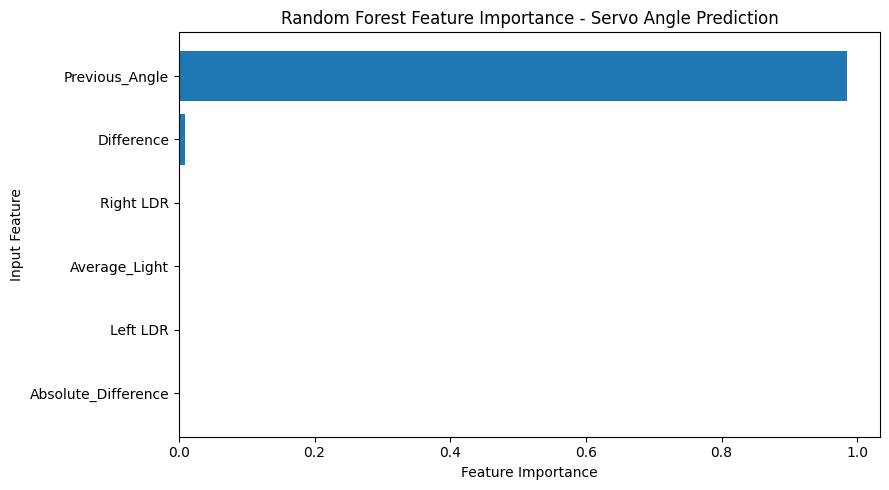

In [ ]:
angle_importance = pd.DataFrame({
    "Feature": X_angle_train.columns,
    "Importance": angle_rf.feature_importances_
}).sort_values(
    "Importance",
    ascending=True
)

print(angle_importance)

plt.figure(figsize=(9, 5))

plt.barh(
    angle_importance["Feature"],
    angle_importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Input Feature")
plt.title("Random Forest Feature Importance - Servo Angle Prediction")

plt.tight_layout()
plt.show()

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Light-only Random Forest",
        "Temporal Random Forest",
        "LSTM"
    ],
    "MAE (degrees)": [
        16.535,
        10.586,
        23.438,
        1.574,
        19.266
    ],
    "RMSE (degrees)": [
        18.783,
        14.110,
        26.716,
        1.751,
        23.797
    ],
    "R²": [
        0.227,
        0.564,
        -3.481,
        0.981,
        -2.382
    ]
})

display(comparison)

,Model,MAE (degrees),RMSE (degrees),R²
0,Linear Regression,16.535,18.783,0.227
1,Random Forest,10.586,14.110,0.564
2,Light-only Random Forest,23.438,26.716,-3.481
3,Temporal Random Forest,1.574,1.751,0.981
4,LSTM,19.266,23.797,-2.382


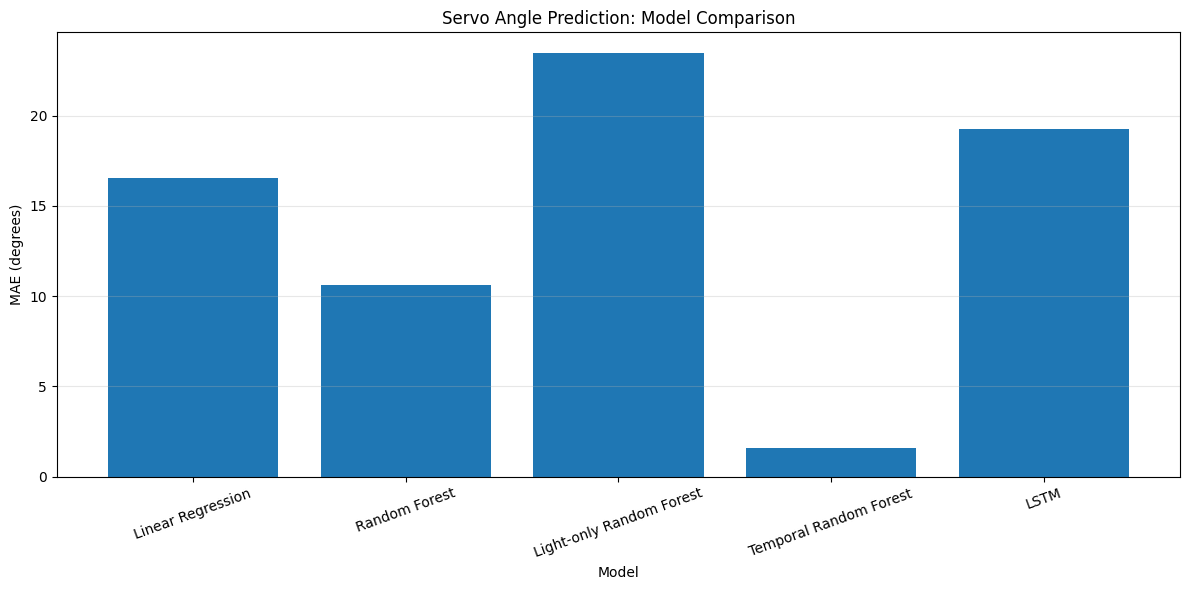

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(
    comparison["Model"],
    comparison["MAE (degrees)"]
)

plt.ylabel("MAE (degrees)")
plt.xlabel("Model")
plt.title("Servo Angle Prediction: Model Comparison")

plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

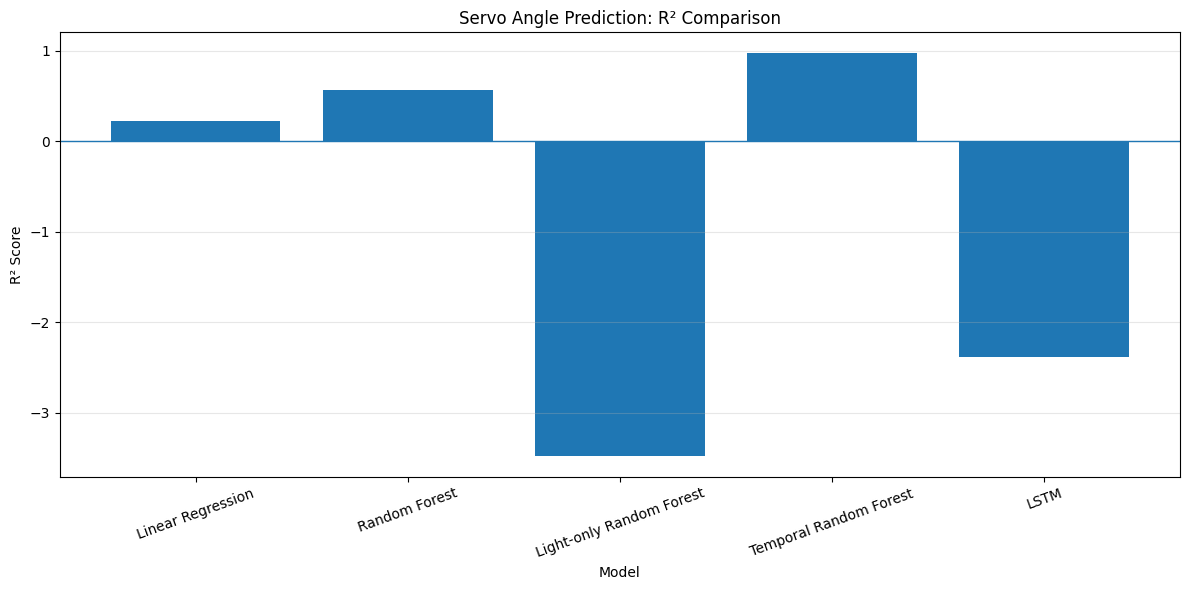

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(
    comparison["Model"],
    comparison["R²"]
)

plt.axhline(
    0,
    linewidth=1
)

plt.ylabel("R² Score")
plt.xlabel("Model")
plt.title("Servo Angle Prediction: R² Comparison")

plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("Final Servo Angle Model")
print("-----------------------")

print("Features:")
for feature in X_angle_train.columns:
    print("-", feature)

print("\nNumber of trees:", len(angle_rf.estimators_))
print("Max depth:", angle_rf.max_depth)
print("Training samples:", len(X_angle_train))
print("Testing samples:", len(X_angle_test))

Final Servo Angle Model
-----------------------
Features:
- Left LDR
- Right LDR
- Difference
- Average_Light
- Absolute_Difference
- Previous_Angle

Number of trees: 200
Max depth: 8
Training samples: 234
Testing samples: 59


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Smaller model for Arduino deployment
small_rf = RandomForestRegressor(
    n_estimators=30,
    max_depth=5,
    random_state=42
)

small_rf.fit(X_angle_train, y_angle_train)

# Prediction
small_pred = small_rf.predict(X_angle_test)

# Metrics
small_mae = mean_absolute_error(y_angle_test, small_pred)
small_rmse = np.sqrt(mean_squared_error(y_angle_test, small_pred))
small_r2 = r2_score(y_angle_test, small_pred)

print("Small Random Forest - Arduino Candidate")
print("---------------------------------------")
print(f"MAE  : {small_mae:.3f} degrees")
print(f"RMSE : {small_rmse:.3f} degrees")
print(f"R²   : {small_r2:.3f}")
print()
print("Trees:", len(small_rf.estimators_))
print("Max depth:", small_rf.max_depth)


Small Random Forest - Arduino Candidate
---------------------------------------
MAE  : 1.671 degrees
RMSE : 1.905 degrees
R²   : 0.977

Trees: 30
Max depth: 5


In [ ]:
# Check the actual size of the Arduino candidate model

total_nodes = sum(
    tree.tree_.node_count
    for tree in small_rf.estimators_
)

max_nodes = max(
    tree.tree_.node_count
    for tree in small_rf.estimators_
)

print("Arduino Candidate Model")
print("-----------------------")
print("Number of trees :", len(small_rf.estimators_))
print("Maximum depth   :", small_rf.max_depth)
print("Total nodes     :", total_nodes)
print("Largest tree    :", max_nodes, "nodes")

# Estimate storage if we store:
# feature(int) + threshold(float) + left(int) + right(int) + value(float)
bytes_per_node = 4 + 4 + 4 + 4 + 4

estimated_bytes = total_nodes * bytes_per_node

print("Estimated model storage:",
      estimated_bytes, "bytes")
print("Estimated storage:",
      round(estimated_bytes / 1024, 2), "KB")

Arduino Candidate Model
-----------------------
Number of trees : 30
Maximum depth   : 5
Total nodes     : 1814
Largest tree    : 63 nodes
Estimated model storage: 36280 bytes
Estimated storage: 35.43 KB


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Test several smaller models
configs = [
    (5, 4),
    (10, 4),
    (15, 4),
    (20, 4),
    (10, 3),
    (15, 3),
    (20, 3)
]

results = []

for trees, depth in configs:

    model = RandomForestRegressor(
        n_estimators=trees,
        max_depth=depth,
        random_state=42
    )

    model.fit(X_angle_train, y_angle_train)

    pred = model.predict(X_angle_test)

    mae = mean_absolute_error(y_angle_test, pred)
    rmse = np.sqrt(mean_squared_error(y_angle_test, pred))
    r2 = r2_score(y_angle_test, pred)

    total_nodes = sum(
        tree.tree_.node_count
        for tree in model.estimators_
    )

    # Approximate storage
    estimated_bytes = total_nodes * 20

    results.append([
        trees,
        depth,
        total_nodes,
        round(estimated_bytes / 1024, 2),
        round(mae, 3),
        round(rmse, 3),
        round(r2, 3)
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Trees",
        "Depth",
        "Total Nodes",
        "Estimated KB",
        "MAE",
        "RMSE",
        "R²"
    ]
)

display(results_df)

,Trees,Depth,Total Nodes,Estimated KB,MAE,RMSE,R²
0,5,4,155,3.03,2.143,2.602,0.957
1,10,4,310,6.05,2.013,2.366,0.965
2,15,4,465,9.08,2.046,2.411,0.964
3,20,4,620,12.11,2.046,2.407,0.964
4,10,3,150,2.93,3.280,3.780,0.910
5,15,3,225,4.39,3.195,3.714,0.913
6,20,3,300,5.86,3.207,3.704,0.914


In [ ]:
# Final compact model for Arduino UNO

arduino_rf = RandomForestRegressor(
    n_estimators=5,
    max_depth=4,
    random_state=42
)

arduino_rf.fit(
    X_angle_train,
    y_angle_train
)

arduino_predictions = arduino_rf.predict(X_angle_test)

arduino_mae = mean_absolute_error(
    y_angle_test,
    arduino_predictions
)

arduino_rmse = np.sqrt(
    mean_squared_error(y_angle_test, arduino_predictions)
)

arduino_r2 = r2_score(
    y_angle_test,
    arduino_predictions
)

print("FINAL ARDUINO MODEL")
print("-------------------")
print("Trees :", len(arduino_rf.estimators_))
print("Depth :", arduino_rf.max_depth)
print("MAE   :", round(arduino_mae, 3), "degrees")
print("RMSE  :", round(arduino_rmse, 3), "degrees")
print("R²    :", round(arduino_r2, 3))

FINAL ARDUINO MODEL
-------------------
Trees : 5
Depth : 4
MAE   : 2.143 degrees
RMSE  : 2.602 degrees
R²    : 0.957


In [ ]:
# Generate Arduino-compatible code from the trained 5-tree Random Forest

def generate_tree_code(tree, tree_id):
    t = tree.tree_
    lines = []

    def recurse(node, depth=0):
        indent = "  " * depth

        # Leaf node
        if t.children_left[node] == -1:
            value = t.value[node][0][0]
            lines.append(
                f"{indent}return {value:.6f}f;"
            )
            return

        feature = t.feature[node]
        threshold = t.threshold[node]

        feature_names = [
            "leftLDR",
            "rightLDR",
            "difference",
            "averageLight",
            "absoluteDifference",
            "previousAngle"
        ]

        feature_name = feature_names[feature]

        lines.append(
            f"{indent}if ({feature_name} <= {threshold:.6f}f) {{"
        )

        recurse(t.children_left[node], depth + 1)

        lines.append(
            f"{indent}}} else {{"
        )

        recurse(t.children_right[node], depth + 1)

        lines.append(
            f"{indent}}}"

        )

    lines.append(f"float tree_{tree_id}(")
    lines.append("  float leftLDR,")
    lines.append("  float rightLDR,")
    lines.append("  float difference,")
    lines.append("  float averageLight,")
    lines.append("  float absoluteDifference,")
    lines.append("  float previousAngle")
    lines.append(") {")

    recurse(0, 1)

    lines.append("}")
    lines.append("")

    return "\n".join(lines)


# Generate all 5 trees
arduino_tree_code = ""

for i, tree in enumerate(arduino_rf.estimators_):
    arduino_tree_code += generate_tree_code(tree, i)


# Generate prediction function
arduino_tree_code += """
float predictServoAngle(
  float leftLDR,
  float rightLDR,
  float difference,
  float averageLight,
  float absoluteDifference,
  float previousAngle
) {

  float prediction = 0.0f;

"""

for i in range(5):
    arduino_tree_code += f"""
  prediction += tree_{i}(
    leftLDR,
    rightLDR,
    difference,
    averageLight,
    absoluteDifference,
    previousAngle
  );
"""

arduino_tree_code += """
  return prediction / 5.0f;
}
"""


print(arduino_tree_code)

float tree_0(
  float leftLDR,
  float rightLDR,
  float difference,
  float averageLight,
  float absoluteDifference,
  float previousAngle
) {
  if (previousAngle <= 96.500000f) {
    if (previousAngle <= 78.000000f) {
      if (previousAngle <= 68.000000f) {
        if (previousAngle <= 60.500000f) {
          return 60.750000f;
        } else {
          return 65.428571f;
        }
      } else {
        if (difference <= -28.000000f) {
          return 69.666667f;
        } else {
          return 76.473684f;
        }
      }
    } else {
      if (previousAngle <= 90.500000f) {
        if (previousAngle <= 86.500000f) {
          return 82.217391f;
        } else {
          return 87.857143f;
        }
      } else {
        if (averageLight <= 445.750000f) {
          return 96.714286f;
        } else {
          return 92.454545f;
        }
      }
    }
  } else {
    if (previousAngle <= 112.500000f) {
      if (difference <= -16.500000f) {
        if (previousAngle <= 100